In [ ]:
# Install required packages
!pip install lingam numpy pandas matplotlib seaborn networkx scikit-learn

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from lingam import VARLiNGAM
import warnings
warnings.filterwarnings('ignore')

In [3]:
# 1. Load Data
# INPUT: Specify your data path
DATA_PATH = 'data/smart-room-hidden-vars_preprocessed.csv'  # Update this path

# Load data
df = pd.read_csv(DATA_PATH)

# Define variable names
var_names = df.columns.tolist()

print(f"Data shape: {df.shape}")
print(f"\nColumns: {var_names}")
print(f"\nFirst few rows:")
display(df.head())
print(f"\nData summary:")
display(df.describe())

Data shape: (1000, 5)

Columns: ['Temperature', 'Humidity', 'AirQuality', 'EnergyConsumption', 'OverallSatisfaction']

First few rows:


,Temperature,Humidity,AirQuality,EnergyConsumption,OverallSatisfaction
0,0.323513,0.237476,0.039730,0.014551,0.999161
1,0.364578,0.228916,0.081207,0.068468,0.747442
2,0.367476,0.213829,0.086368,0.158265,0.745041
3,0.363106,0.145473,0.066289,0.004361,0.748944
4,0.323132,0.070860,0.089230,0.133699,0.761137



Data summary:


,Temperature,Humidity,AirQuality,EnergyConsumption,OverallSatisfaction
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,0.634900,0.702083,0.662873,0.244050,0.179110
std,0.277294,0.241056,0.264661,0.165616,0.167126
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.375193,0.583428,0.481302,0.126605,0.086081
50%,0.717263,0.737447,0.696060,0.200154,0.162904
75%,0.863014,0.893815,0.901344,0.314491,0.209343
max,1.000000,1.000000,1.000000,1.000000,1.000000


In [29]:
# Cell 3: Generate Synthetic Data with Cycles
def generate_all_cycle_types(n_samples=500, noise=0.1, seed=42):
    """Generate data with strong cycles"""
    np.random.seed(seed)
    data = np.zeros((n_samples, 5))
    
    for t in range(1, n_samples):
        # X ↔ Y strong bidirectional
        data[t, 0] = 0.5 * data[t-1, 0] + 0.6 * data[t, 1] + np.random.randn() * noise
        data[t, 1] = 0.5 * data[t-1, 1] + 0.6 * data[t, 0] + np.random.randn() * noise
        
        # Rest of variables
        data[t, 2] = 0.4 * data[t-1, 2] + 0.5 * data[t-1, 1] + np.random.randn() * noise
        data[t, 3] = 0.4 * data[t-1, 3] + 0.5 * data[t-1, 2] + np.random.randn() * noise
        data[t, 4] = 0.4 * data[t-1, 4] + np.random.randn() * noise
    
    return pd.DataFrame(data, columns=['X', 'Y', 'Z', 'W', 'V'])

df = generate_all_cycle_types()
var_names = df.columns.tolist()
print(f"Generated data with all cycle types")
print(f"Shape: {df.shape}")
print(f"Variables: {var_names}")

Generated data with all cycle types
Shape: (500, 5)
Variables: ['X', 'Y', 'Z', 'W', 'V']


In [4]:
# Cell 4: Fit VARLiNGAM
model = VARLiNGAM(lags=5, criterion='bic', prune=True)
model.fit(df.values)

n_lags = len(model.adjacency_matrices_)
causal_order = [var_names[i] for i in model.causal_order_]

print(f"Fitted VARLiNGAM model")
print(f"Number of lags: {n_lags}")
print(f"Causal order: {causal_order}")

Fitted VARLiNGAM model
Number of lags: 3
Causal order: ['Humidity', 'EnergyConsumption', 'OverallSatisfaction', 'AirQuality', 'Temperature']


In [5]:
# Display adjacency matrices for each lag
print("Adjacency Matrix B0 (contemporaneous effects):")
print(model.adjacency_matrices_[0])

optimal_lags = len(model.adjacency_matrices_)
print(f"Optimal lag order selected: {optimal_lags}")

Adjacency Matrix B0 (contemporaneous effects):
[[0.         0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.        ]
 [0.         0.         0.         0.05472215 0.        ]]
Optimal lag order selected: 3


In [6]:
# Cell 5: Extract All Edges (excluding self-loops)
def extract_edges(model, var_names, threshold=0.01):
    edges = []
    n_lags = len(model.adjacency_matrices_)
    
    for lag_idx in range(n_lags):
        adj = model.adjacency_matrices_[lag_idx]
        for i in range(len(var_names)):
            for j in range(len(var_names)):
                # Skip self-loops (i == j)
                if i == j:
                    continue
                    
                w = adj[i, j]
                if abs(w) > threshold:
                    edges.append({
                        'source': var_names[i],
                        'target': var_names[j],
                        'lag': lag_idx,
                        'weight': w,
                        'abs_weight': abs(w)
                    })
    return pd.DataFrame(edges)

edges_df = extract_edges(model, var_names)
print(f"Total edges (no self-loops): {len(edges_df)}")
print(f"\nEdges by lag:")
print(edges_df.groupby('lag').size())

Total edges (no self-loops): 6

Edges by lag:
lag
0    1
1    4
2    1
dtype: int64


In [7]:
# Cell 6: Detect Cycles
def detect_cycles(edges_df, lag=0):
    """Detect cycles at specific lag"""
    lag_edges = edges_df[edges_df['lag'] == lag]
    
    G = nx.DiGraph()
    for _, edge in lag_edges.iterrows():
        G.add_edge(edge['source'], edge['target'], weight=edge['weight'])
    
    try:
        cycles = list(nx.simple_cycles(G))
        return cycles, G
    except:
        return [], G

# Check each lag for cycles
for lag in sorted(edges_df['lag'].unique()):
    cycles, graph = detect_cycles(edges_df, lag)
    print(f"\nLag {lag}: {len(cycles)} cycles detected")
    if cycles:
        for cycle in cycles:
            print(f"  {' → '.join(cycle)} → {cycle[0]}")


Lag 0: 0 cycles detected

Lag 1: 0 cycles detected

Lag 2: 0 cycles detected


In [8]:
# Cell 7: Print Final Causal Graph as Tuples (no duplicates)
print("\n" + "="*60)
print("FINAL CAUSAL GRAPH AS TUPLES [(source, target)]")
print("="*60)

# Remove duplicates - keep only unique (source, target) pairs
unique_tuples = list(set([(row['source'], row['target']) for _, row in edges_df.iterrows()]))
print(f"\nUnique edges ({len(unique_tuples)} total):")
print(unique_tuples)

# Lag 0 only (contemporaneous)
lag0 = edges_df[edges_df['lag'] == 0]
lag0_tuples = [(row['source'], row['target']) for _, row in lag0.iterrows()]
print(f"\nLag 0 only ({len(lag0_tuples)} edges):")
print(lag0_tuples)

# By lag (shows why duplicates exist)
print("\nGrouped by lag:")
for lag in sorted(edges_df['lag'].unique()):
    lag_edges = edges_df[edges_df['lag'] == lag]
    lag_tuples = [(row['source'], row['target']) for _, row in lag_edges.iterrows()]
    print(f"  Lag {lag}: {lag_tuples}")


FINAL CAUSAL GRAPH AS TUPLES [(source, target)]

Unique edges (6 total):
[('EnergyConsumption', 'Temperature'), ('OverallSatisfaction', 'EnergyConsumption'), ('OverallSatisfaction', 'Humidity'), ('EnergyConsumption', 'Humidity'), ('EnergyConsumption', 'AirQuality'), ('OverallSatisfaction', 'Temperature')]

Lag 0 only (1 edges):
[('OverallSatisfaction', 'EnergyConsumption')]

Grouped by lag:
  Lag 0: [('OverallSatisfaction', 'EnergyConsumption')]
  Lag 1: [('EnergyConsumption', 'Temperature'), ('EnergyConsumption', 'Humidity'), ('OverallSatisfaction', 'Temperature'), ('OverallSatisfaction', 'Humidity')]
  Lag 2: [('EnergyConsumption', 'AirQuality')]


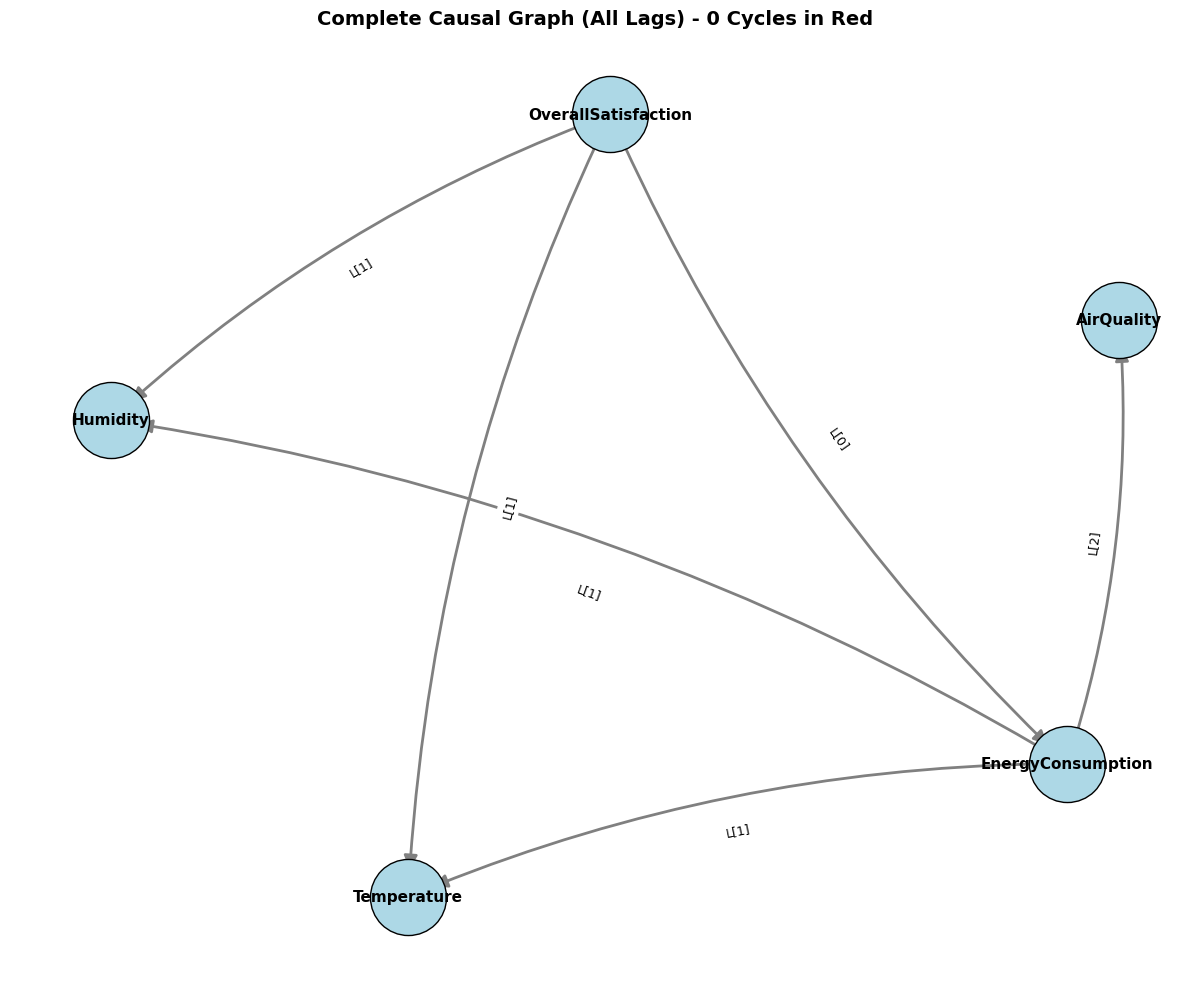


Total cycles detected: 0


In [9]:
# Cell 8: Visualize with proper arrows
def build_complete_graph(edges_df):
    """Build graph with all edges from all lags"""
    G = nx.DiGraph()
    for _, edge in edges_df.iterrows():
        if G.has_edge(edge['source'], edge['target']):
            G[edge['source']][edge['target']]['lags'].append(edge['lag'])
        else:
            G.add_edge(edge['source'], edge['target'], 
                      weight=edge['weight'],
                      lags=[edge['lag']])
    return G

graph_all = build_complete_graph(edges_df)

try:
    cycles_all = list(nx.simple_cycles(graph_all))
except:
    cycles_all = []

plt.figure(figsize=(12, 10))
pos = nx.spring_layout(graph_all, k=2, seed=42)

# Identify cycle edges
cycle_edges = set()
for cycle in cycles_all:
    for i in range(len(cycle)):
        cycle_edges.add((cycle[i], cycle[(i+1) % len(cycle)]))

# Draw nodes
nx.draw_networkx_nodes(graph_all, pos, node_color='lightblue', 
                       node_size=3000, edgecolors='black')
nx.draw_networkx_labels(graph_all, pos, font_size=11, font_weight='bold')

# Draw edges individually
for edge in graph_all.edges():
    color = 'red' if edge in cycle_edges else 'gray'
    width = 3 if edge in cycle_edges else 2
    
    nx.draw_networkx_edges(
        graph_all, pos,
        edgelist=[edge],
        width=width,
        arrowsize=20,
        arrowstyle='-|>',
        connectionstyle='arc3,rad=0.1',
        edge_color=color,
        min_source_margin=20,
        min_target_margin=20
    )

# Edge labels
edge_labels = {(u, v): f"L{graph_all[u][v]['lags']}" for u, v in graph_all.edges()}
nx.draw_networkx_edge_labels(graph_all, pos, edge_labels, font_size=9)

plt.title(f'Complete Causal Graph (All Lags) - {len(cycles_all)} Cycles in Red', 
          fontsize=14, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

print(f"\nTotal cycles detected: {len(cycles_all)}")